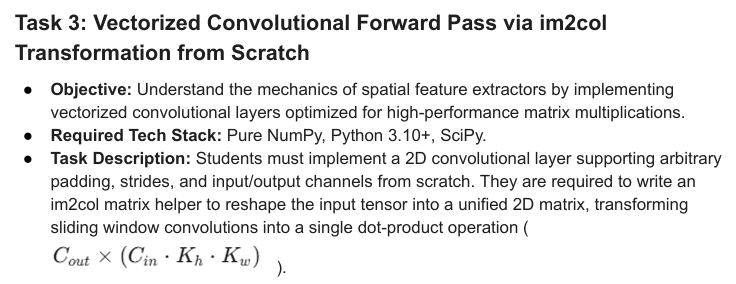

In [1]:
!pip install numpy scipy matplotlib

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
np.random.seed(42)

X = np.random.randn(1, 3, 5, 5)

print("Input shape:", X.shape)

Input shape: (1, 3, 5, 5)


In [4]:
out_channels = 2
in_channels = 3

kernel_size = 3

W = np.random.randn(
    out_channels,
    in_channels,
    kernel_size,
    kernel_size
)

b = np.zeros(out_channels)

print("Filter shape:", W.shape)

Filter shape: (2, 3, 3, 3)


In [5]:
padding = 1
stride = 1

In [6]:
H, W_input = X.shape[2:]

K = kernel_size
P = padding
S = stride

H_out = (H + 2 * P - K) // S + 1
W_out = (W_input + 2 * P - K) // S + 1

print("Output height:", H_out)
print("Output width :", W_out)

Output height: 5
Output width : 5


In [7]:
def im2col(X, kernel_size, padding=0, stride=1):

    N, C, H, W = X.shape

    K = kernel_size

    # Add padding
    X_pad = np.pad(
        X,
        (
            (0, 0),
            (0, 0),
            (padding, padding),
            (padding, padding)
        ),
        mode="constant"
    )

    H_out = (
        H + 2 * padding - K
    ) // stride + 1

    W_out = (
        W + 2 * padding - K
    ) // stride + 1

    cols = []

    for i in range(H_out):

        for j in range(W_out):

            patch = X_pad[
                :,
                :,
                i * stride:i * stride + K,
                j * stride:j * stride + K
            ]

            cols.append(
                patch.reshape(N, -1)
            )

    cols = np.stack(cols, axis=1)

    return cols

In [8]:
X_col = im2col(
    X,
    kernel_size=3,
    padding=1,
    stride=1
)

print("im2col shape:", X_col.shape)

im2col shape: (1, 25, 27)


In [9]:
W_col = W.reshape(
    out_channels,
    -1
)

print("Reshaped filters:", W_col.shape)

Reshaped filters: (2, 27)


In [10]:
output = W_col @ X_col[0].T

In [11]:
output = output + b.reshape(-1, 1)

In [12]:
output = output.reshape(
    out_channels,
    H_out,
    W_out
)

output = output.reshape(
    1,
    out_channels,
    H_out,
    W_out
)

print("Final output:", output.shape)

Final output: (1, 2, 5, 5)


In [13]:
def conv2d_im2col(
    X,
    filters,
    bias,
    padding=0,
    stride=1
):

    N, C, H, W = X.shape

    F, _, K, _ = filters.shape

    # im2col
    X_col = im2col(
        X,
        K,
        padding,
        stride
    )

    # Flatten filters
    filters_col = filters.reshape(
        F,
        -1
    )

    # Matrix multiplication
    output = np.matmul(
        X_col,
        filters_col.T
    )

    # Add bias
    output += bias

    # Output dimensions
    H_out = (
        H + 2 * padding - K
    ) // stride + 1

    W_out = (
        W + 2 * padding - K
    ) // stride + 1

    # Reshape
    output = output.reshape(
        N,
        H_out,
        W_out,
        F
    )

    output = output.transpose(
        0,
        3,
        1,
        2
    )

    return output

In [14]:
output = conv2d_im2col(
    X,
    W,
    b,
    padding=1,
    stride=1
)

print("Input :", X.shape)
print("Output:", output.shape)

Input : (1, 3, 5, 5)
Output: (1, 2, 5, 5)


In [15]:
stride = 2

In [16]:
output_stride2 = conv2d_im2col(
    X,
    W,
    b,
    padding=1,
    stride=2
)

print(
    "Output with stride 2:",
    output_stride2.shape
)

Output with stride 2: (1, 2, 3, 3)


In [17]:
output_no_padding = conv2d_im2col(
    X,
    W,
    b,
    padding=0,
    stride=1
)

print(
    "Output without padding:",
    output_no_padding.shape
)

Output without padding: (1, 2, 3, 3)


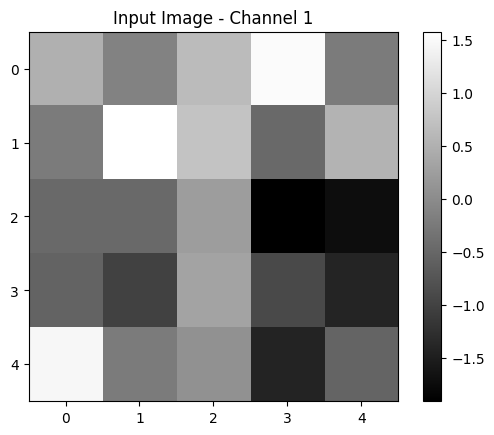

In [18]:
plt.imshow(
    X[0, 0],
    cmap="gray"
)

plt.title("Input Image - Channel 1")

plt.colorbar()

plt.show()

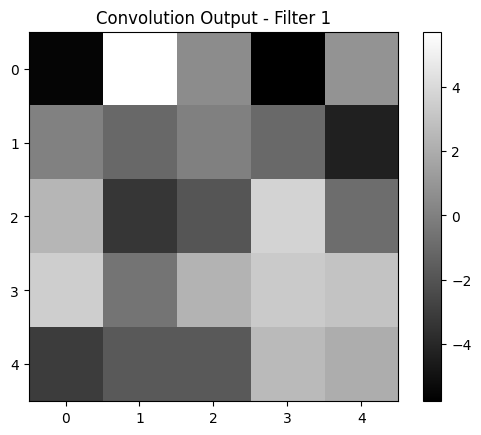

In [19]:
plt.imshow(
    output[0, 0],
    cmap="gray"
)

plt.title(
    "Convolution Output - Filter 1"
)

plt.colorbar()

plt.show()

In [20]:
print("Original image:")
print(X[0, 0])

print("\nFirst im2col patch:")

print(
    X_col[0, 0].reshape(
        3, 3, 3
    )
)

Original image:
[[ 0.49671415 -0.1382643   0.64768854  1.52302986 -0.23415337]
 [-0.23413696  1.57921282  0.76743473 -0.46947439  0.54256004]
 [-0.46341769 -0.46572975  0.24196227 -1.91328024 -1.72491783]
 [-0.56228753 -1.01283112  0.31424733 -0.90802408 -1.4123037 ]
 [ 1.46564877 -0.2257763   0.0675282  -1.42474819 -0.54438272]]

First im2col patch:
[[[ 0.          0.          0.        ]
  [ 0.          0.49671415 -0.1382643 ]
  [ 0.         -0.23413696  1.57921282]]

 [[ 0.          0.          0.        ]
  [ 0.          0.11092259 -1.15099358]
  [ 0.         -0.60170661  1.85227818]]

 [[ 0.          0.          0.        ]
  [ 0.          0.32408397 -0.38508228]
  [ 0.          0.93128012 -0.83921752]]]
